# Deepfake Detection: EDA и постановка задачи

##  Описание задачи

В данном соревновании требуется построить модель бинарной классификации изображений лиц, которая способна различать:

- **0 — реальные изображения (real)**
- **1 — синтетические изображения (deepfake)**

Данные:
- изображения размером 256×256
- реальные лица — фотографии (Flickr)
- синтетические — сгенерированы с помощью StyleGAN

---

##  Цель

Построить сверточную нейронную сеть, способную максимально точно выявлять deepfake-изображения.

---

##  Особенности датасета

- Дисбаланс классов
- Шум и артефакты
- Высокая визуальная схожесть классов

---

##  Метрика качества

Основная метрика:

$$
F1 = \frac{2 \cdot Precision \cdot Recall}{Precision + Recall}
$$
---

##  Важный момент задачи

Приоритет:

- минимизация ошибки второго рода

То есть:

- нельзя пропускать deepfake
- важно максимизировать **Recall**

Но при этом:
- нельзя сильно терять **Precision**

---

##  Что оценивается

- качество модели (F1-score)
- глубина исследований
- работа с данными (EDA)
- архитектура модели
- воспроизводимость

---

##  Ограничения

- запрещено использовать готовые архитектуры (ResNet, EfficientNet и т.д.)
- модель должна быть реализована с нуля

---
## План разведочного анализа (EDA)

Цель EDA — понять структуру данных и выявить особенности, которые могут быть полезны для построения модели распознавания deepfake.

В рамках анализа будут выполнены следующие шаги:

### 1. Проверка структуры данных
- проверка наличия файлов и их соответствия разметке
- анализ таблицы `train_solution.csv`
- проверка корректности меток

### 2. Анализ распределения классов
- подсчёт количества real / fake
- оценка дисбаланса классов
- вывод о необходимости балансировки (sampler / pos_weight)

### 3. Визуальный анализ изображений
- просмотр случайных примеров каждого класса
- выявление визуальных различий и артефактов
- формирование гипотез о признаках deepfake

### 4. Проверка базовых характеристик изображений
- размер изображений
- формат данных
- наличие аномалий

### 5. Анализ статистик изображений
- распределение яркости
- анализ контраста
- сравнение статистик между классами

### 6. Анализ шума и артефактов
- выявление локальных шумовых выбросов
- визуальная оценка дефектов
- проверка гипотезы о наличии шумовых паттернов

### 7. Исследование методов предобработки
- применение медианного подавления шума
- сравнение изображений до и после обработки
- оценка влияния на структуру изображения

### 8. Формулировка выводов
- ключевые особенности датасета
- потенциально полезные признаки
- рекомендации для построения модели

# **Загрузка датасета с Kaggle**

In [1]:
!pip install -q kaggle
from google.colab import files
files.upload()
!mkdir -p /root/.kaggle
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
!kaggle competitions list
!kaggle competitions download -c ml-intensive-yandex-academy-spring-2026 -p /content/
!unzip -o -q /content/ml-intensive-yandex-academy-spring-2026.zip -d /content/data

Saving kaggle.json to kaggle.json
ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection             2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/

In [2]:
import os
import pandas as pd

BASE_PATH = "/content/data/dataset"
TRAIN_DIR = f"{BASE_PATH}/train_images"
TEST_DIR = f"{BASE_PATH}/test_images"
CSV_PATH = f"{BASE_PATH}/train_solution.csv"

df = pd.read_csv(CSV_PATH)

if "target_feature" not in df.columns:
    df.columns = ["Id", "target_feature"]

df["Id"] = df["Id"].astype(int)
df["target_feature"] = df["target_feature"].astype(int)

print(df.head())
print(df.shape)

   Id  target_feature
0   1               1
1   2               1
2   3               0
3   4               0
4   5               0
(49999, 2)


# **Анализ распределения классов**

target_feature
0    41499
1     8500
Name: count, dtype: int64


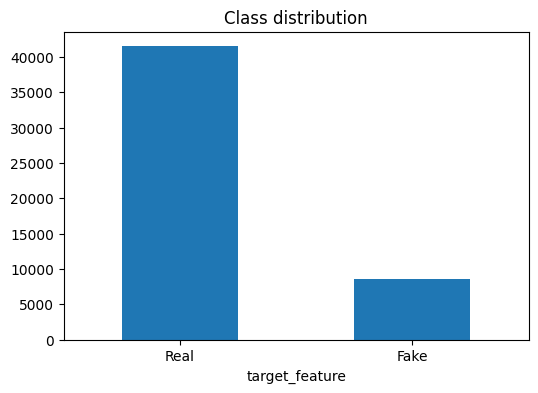

In [3]:
import matplotlib.pyplot as plt

class_counts = df["target_feature"].value_counts()

print(class_counts)

plt.figure(figsize=(6,4))
class_counts.plot(kind="bar")
plt.title("Class distribution")
plt.xticks([0,1], ["Real", "Fake"], rotation=0)
plt.show()

# **Визуализация изображений**

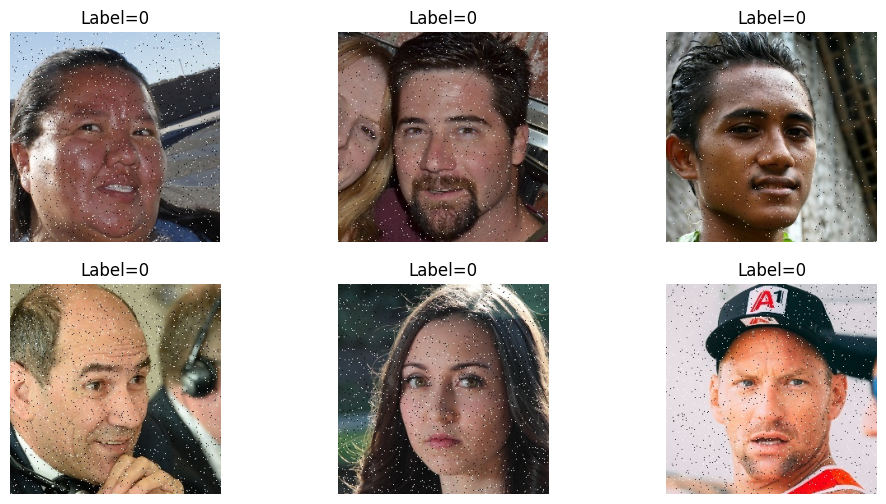

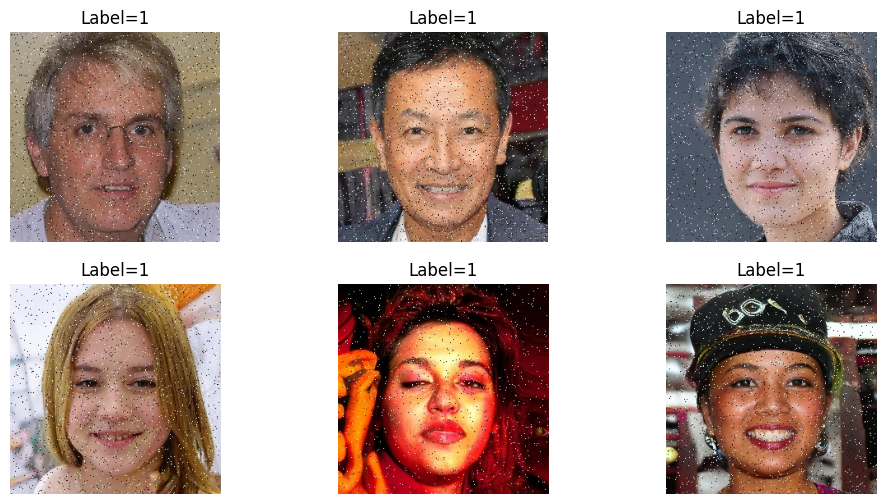

In [4]:
from PIL import Image

def show_images(df, label, n=6):
    sample = df[df["target_feature"] == label].sample(n)

    plt.figure(figsize=(12,6))
    for i, row in enumerate(sample.itertuples(), 1):
        img = Image.open(f"{TRAIN_DIR}/{row.Id}.jpg")
        plt.subplot(2,3,i)
        plt.imshow(img)
        plt.title(f"Label={label}")
        plt.axis("off")
    plt.show()

show_images(df, 0)
show_images(df, 1)

# **Анализ яркости**

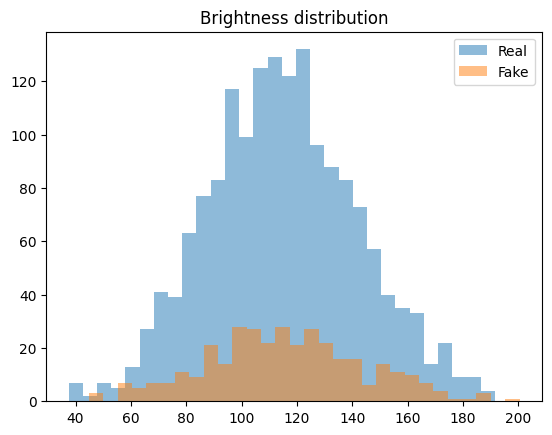

In [5]:
import numpy as np

def compute_brightness(img_path):
    img = Image.open(img_path).convert("L")
    return np.array(img).mean()

sample_df = df.sample(2000)

brightness = []
labels = []

for row in sample_df.itertuples():
    path = f"{TRAIN_DIR}/{row.Id}.jpg"
    brightness.append(compute_brightness(path))
    labels.append(row.target_feature)

brightness = np.array(brightness)
labels = np.array(labels)

plt.hist(brightness[labels==0], bins=30, alpha=0.5, label="Real")
plt.hist(brightness[labels==1], bins=30, alpha=0.5, label="Fake")
plt.legend()
plt.title("Brightness distribution")
plt.show()

# **Размеры изображений**

In [6]:
sizes = []

for fname in os.listdir(TRAIN_DIR)[:500]:
    img = Image.open(f"{TRAIN_DIR}/{fname}")
    sizes.append(img.size)

print(set(sizes))

{(256, 256)}


# **Подавление локального шума медианным фильтром**

В изображениях могут встречаться локальные шумовые выбросы: слишком тёмные или слишком яркие пиксели, которые выбиваются из окружения.  
Один из способов аккуратно бороться с такими артефактами — использовать локальную медианную замену.

Идея метода:
- ищем подозрительные пиксели, близкие к чёрному или белому;
- для таких пикселей рассматриваем окрестность `3×3`;
- заменяем значение пикселя на медиану по соседям.

Преимущество такого подхода в том, что он подавляет импульсный шум, но сохраняет границы и резкость лучше, чем простое усреднение.

In [7]:
import numpy as np

def remove_noise_preserve_sharpness(image):
    denoised = image.copy()
    h, w = image.shape[:2]

    threshold = 30
    high_noise = image > (255 - threshold)
    low_noise = image < threshold
    noise_mask = high_noise | low_noise

    def get_safe_neighborhood(img, y, x):
        y_start = max(0, y - 1)
        y_end = min(h, y + 2)
        x_start = max(0, x - 1)
        x_end = min(w, x + 2)
        neighbors = img[y_start:y_end, x_start:x_end]
        return neighbors

    for y in range(h):
        for x in range(w):
            if np.any(noise_mask[y, x]):
                neighborhood = get_safe_neighborhood(image, y, x)
                denoised[y, x] = np.median(neighborhood, axis=(0, 1))

    return denoised

# **Картинки до / после подавления шума**

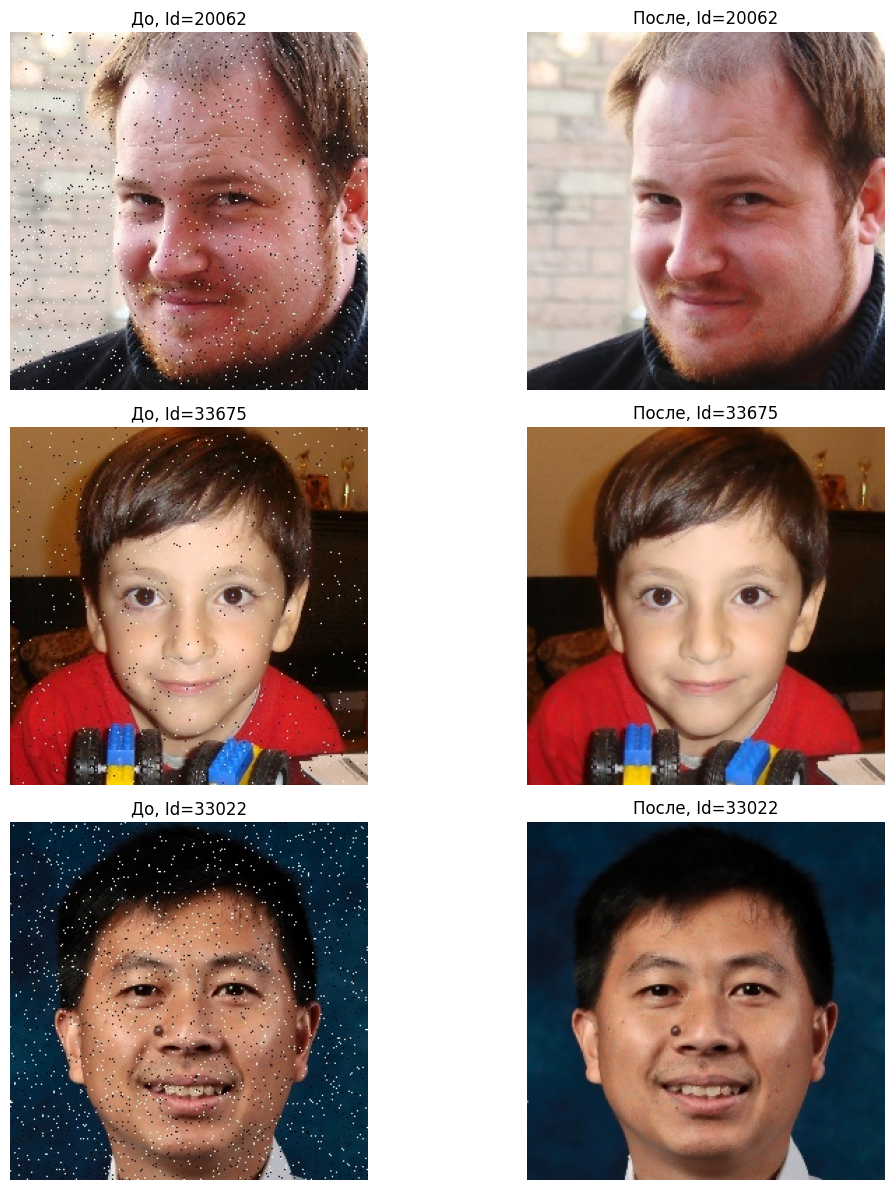

In [8]:
sample_ids = df.sample(3, random_state=17)["Id"].tolist()

plt.figure(figsize=(12, 12))

for i, img_id in enumerate(sample_ids, start=1):
    img_path = os.path.join(TRAIN_DIR, f"{img_id}.jpg")
    img = Image.open(img_path).convert("RGB")
    img_np = np.array(img)
    denoised_np = remove_noise_preserve_sharpness(img_np)

    plt.subplot(3, 2, 2*i - 1)
    plt.imshow(img_np)
    plt.title(f"До, Id={img_id}")
    plt.axis("off")

    plt.subplot(3, 2, 2*i)
    plt.imshow(denoised_np.astype(np.uint8))
    plt.title(f"После, Id={img_id}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# **Выводы**

В ходе анализа данных было выявлено:

- изображения имеют фиксированный размер 256×256
- наблюдается (не)сильный дисбаланс классов
- распределения яркости частично различаются
- визуально deepfake изображения могут содержать артефакты

На основе этого:
- необходимо использовать аугментации
- учитывать дисбаланс (pos_weight / sampler)
- применять достаточно мощную CNN

EDA позволяет сформировать гипотезу о наличии различимых паттернов между real и fake изображениями.